In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from medmnist import ChestMNIST
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

torch.manual_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device utilisé :", device)

Device utilisé : cpu


In [8]:
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5057], std=[0.2896]),
])

train_dataset = ChestMNIST(split='train', transform=transform, download=False, size=64)
test_dataset  = ChestMNIST(split='test',  transform=transform, download=False, size=64)

# Garder uniquement les images sans aucune pathologie (toutes les labels = 0)
normal_indices = [i for i in range(len(train_dataset)) 
                  if train_dataset[i][1].sum() == 0]

normal_dataset = Subset(train_dataset, normal_indices)
normal_loader  = DataLoader(normal_dataset, batch_size=32, shuffle=True, num_workers=0)

# Loader complet pour tester la détection d'anomalies
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=0)

print(f"Images normales pour entraînement : {len(normal_dataset)}")
print(f"Images test totales : {len(test_dataset)}")

Images normales pour entraînement : 42405
Images test totales : 22433


In [9]:
class Autoencoder(nn.Module):
    def __init__(self):
        super(Autoencoder, self).__init__()
        
        # Encodeur : compresse l'image
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),  # 64x64 → 64x64
            nn.ReLU(),
            nn.MaxPool2d(2),                              # 64x64 → 32x32
            nn.Conv2d(32, 64, kernel_size=3, padding=1), # 32x32 → 32x32
            nn.ReLU(),
            nn.MaxPool2d(2),                              # 32x32 → 16x16
            nn.Conv2d(64, 128, kernel_size=3, padding=1),# 16x16 → 16x16
            nn.ReLU(),
            nn.MaxPool2d(2)                               # 16x16 → 8x8
        )
        
        # Décodeur : reconstruit l'image
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2),  # 8x8 → 16x16
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2),   # 16x16 → 32x32
            nn.ReLU(),
            nn.ConvTranspose2d(32, 1, kernel_size=2, stride=2),    # 32x32 → 64x64
            nn.Sigmoid()
        )
    
    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

model_ae = Autoencoder().to(device)
print(model_ae)
print(f"\nNombre de paramètres : {sum(p.numel() for p in model_ae.parameters()):,}")

Autoencoder(
  (encoder): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (decoder): Sequential(
    (0): ConvTranspose2d(128, 64, kernel_size=(2, 2), stride=(2, 2))
    (1): ReLU()
    (2): ConvTranspose2d(64, 32, kernel_size=(2, 2), stride=(2, 2))
    (3): ReLU()
    (4): ConvTranspose2d(32, 1, kernel_size=(2, 2), stride=(2, 2))
    (5): Sigmoid()
  )
)

Nombre de paramètres : 133,857


In [10]:
# MSE : mesure l'erreur de reconstruction pixel par pixel
criterion_ae = nn.MSELoss()

optimizer_ae = optim.Adam(model_ae.parameters(), lr=1e-3)

print("Critère : MSELoss")
print("Optimiseur : Adam lr=1e-3")

Critère : MSELoss
Optimiseur : Adam lr=1e-3


In [11]:
NUM_EPOCHS = 10
losses = []

for epoch in range(NUM_EPOCHS):
    model_ae.train()
    total_loss = 0
    
    for images, _ in normal_loader:
        images = images.to(device)
        
        optimizer_ae.zero_grad()
        reconstructed = model_ae(images)
        loss = criterion_ae(reconstructed, images)
        loss.backward()
        optimizer_ae.step()
        
        total_loss += loss.item()
    
    avg_loss = total_loss / len(normal_loader)
    losses.append(avg_loss)
    print(f"Epoch {epoch+1}/{NUM_EPOCHS} — Loss: {avg_loss:.6f}")

# Sauvegarder le modèle
save_path = r'C:\Users\ONGOLO YVAN\Desktop\chest-xray-triage\src\models\autoencoder_best.pt'
torch.save(model_ae.state_dict(), save_path)
print("\nModèle autoencodeur sauvegardé")

Epoch 1/10 — Loss: 0.421975
Epoch 2/10 — Loss: 0.411617
Epoch 3/10 — Loss: 0.410964


KeyboardInterrupt: 

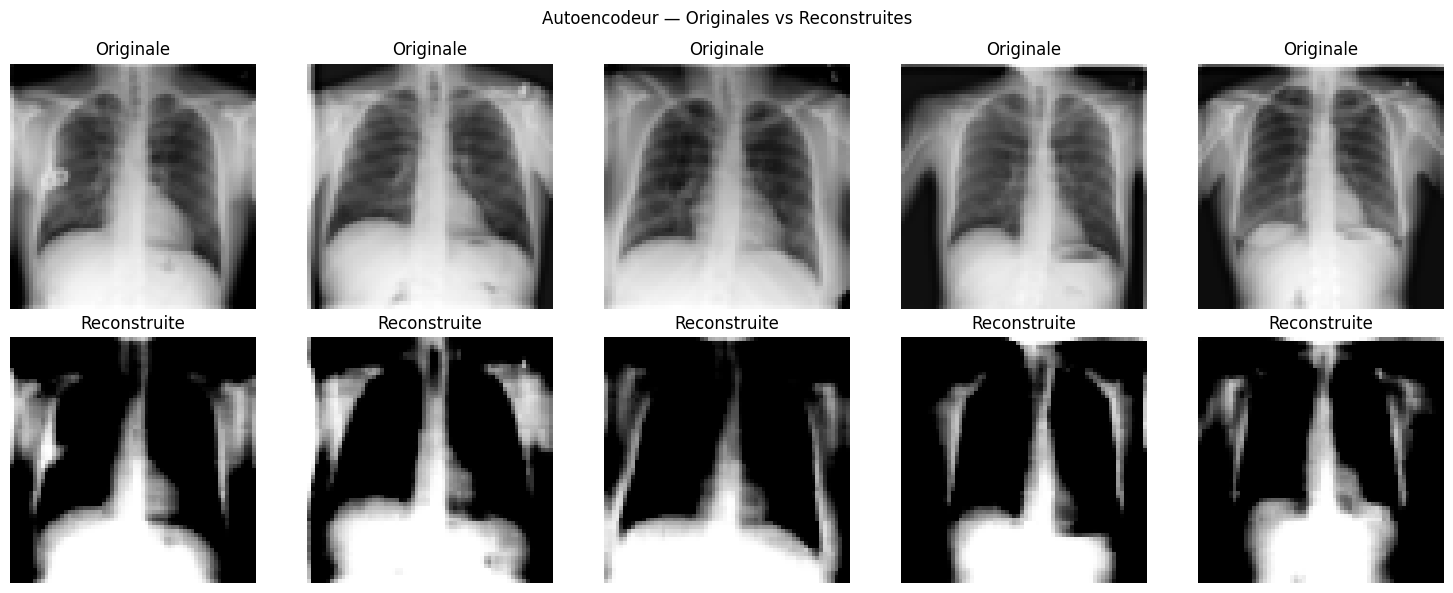

In [ ]:
model_ae.eval()
images, _ = next(iter(test_loader))
images = images.to(device)

with torch.no_grad():
    reconstructed = model_ae(images)

# Afficher 5 images originales vs reconstruites
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for i in range(5):
    # Image originale
    axes[0, i].imshow(images[i].cpu().squeeze(), cmap='gray')
    axes[0, i].set_title('Originale')
    axes[0, i].axis('off')
    
    # Image reconstruite
    axes[1, i].imshow(reconstructed[i].cpu().squeeze(), cmap='gray')
    axes[1, i].set_title('Reconstruite')
    axes[1, i].axis('off')

plt.suptitle("Autoencodeur — Originales vs Reconstruites")
plt.tight_layout()
plt.show()

Score moyen : 0.4215
Score max   : 2.3630
Seuil (95e percentile) : 0.8096
Images détectées comme anomalies : 1122


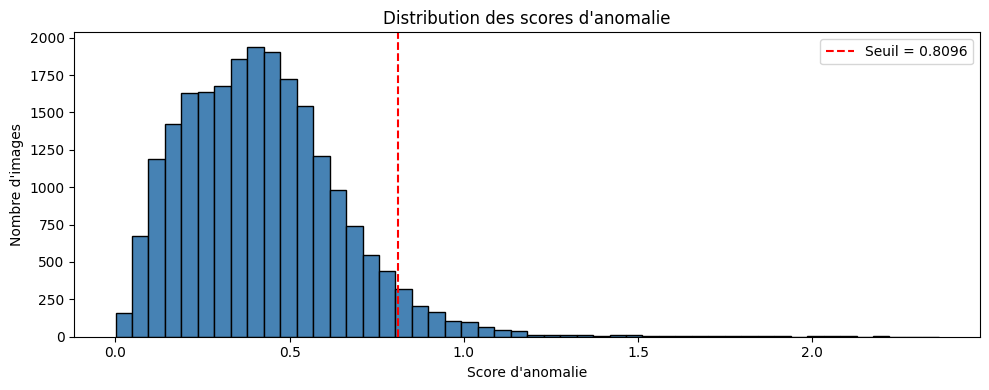

In [12]:
model_ae.eval()
scores = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        reconstructed = model_ae(images)
        
        # Score d'anomalie = erreur de reconstruction par image
        erreur = ((images - reconstructed) ** 2).mean(dim=[1, 2, 3])
        scores.extend(erreur.cpu().numpy())
        all_labels.extend(labels.numpy())

scores = np.array(scores)
all_labels = np.array(all_labels)

# Seuil au percentile 95 sur le test set
seuil = np.percentile(scores, 95)
print(f"Score moyen : {scores.mean():.4f}")
print(f"Score max   : {scores.max():.4f}")
print(f"Seuil (95e percentile) : {seuil:.4f}")
print(f"Images détectées comme anomalies : {(scores > seuil).sum()}")

# Histogramme des scores
plt.figure(figsize=(10, 4))
plt.hist(scores, bins=50, color='steelblue', edgecolor='black')
plt.axvline(seuil, color='red', linestyle='--', label=f'Seuil = {seuil:.4f}')
plt.xlabel("Score d'anomalie")
plt.ylabel("Nombre d'images")
plt.title("Distribution des scores d'anomalie")
plt.legend()
plt.tight_layout()
plt.show()

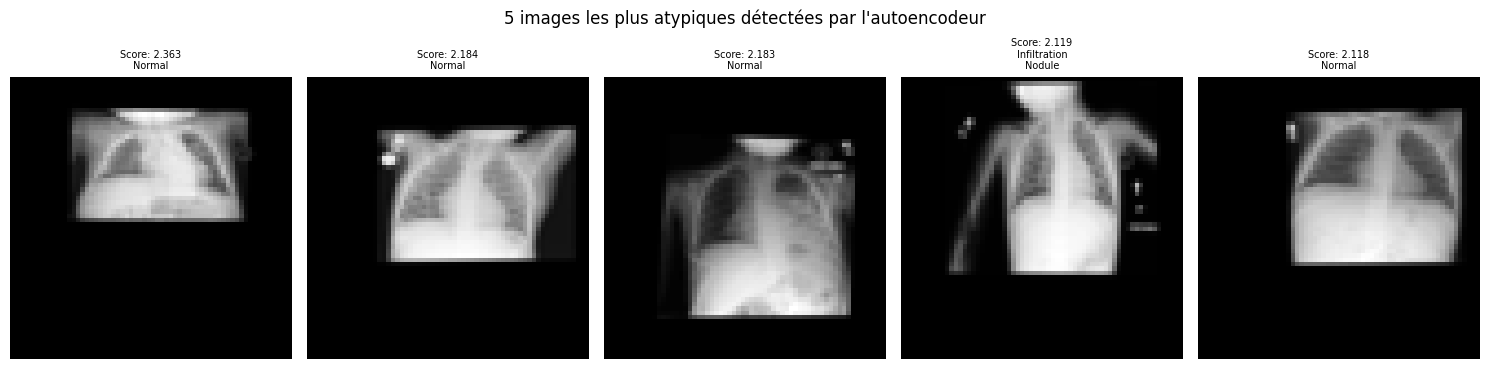

In [13]:
LABELS = [
    "Atelectasis", "Cardiomegaly", "Effusion", "Infiltration",
    "Mass", "Nodule", "Pneumonia", "Pneumothorax",
    "Consolidation", "Edema", "Emphysema", "Fibrosis",
    "Pleural Thickening", "Hernia"
]

# Trouver les 5 images avec le score d'anomalie le plus élevé
top5_indices = np.argsort(scores)[-5:][::-1]

fig, axes = plt.subplots(1, 5, figsize=(15, 4))
for i, idx in enumerate(top5_indices):
    img, label = test_dataset[idx]
    axes[i].imshow(img.squeeze(), cmap='gray')
    pathologies = [LABELS[j] for j, v in enumerate(label) if v == 1]
    titre = '\n'.join(pathologies) if pathologies else "Normal"
    axes[i].set_title(f"Score: {scores[idx]:.3f}\n{titre}", fontsize=7)
    axes[i].axis('off')

plt.suptitle("5 images les plus atypiques détectées par l'autoencodeur")
plt.tight_layout()
plt.show()